# Crop Yield Prediction - Data Preprocessing & Feature Engineering

## 🔧 Xử Lý Dữ Liệu Và Kỹ Thuật Tạo Features

Notebook này thực hiện:
1. **Data Cleaning** - Làm sạch dữ liệu
2. **Feature Engineering** - Tạo các features mới
3. **Feature Selection** - Chọn features quan trọng

---

## 1. Load and Preprocess Data

In [10]:
import sys
from pathlib import Path

# Thêm src vào path để import modules
src_path = Path('../src')
sys.path.insert(0, str(src_path.absolute()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Import từ modules
from data.loader import DataLoader
from data.cleaner import DataCleaner

print("✓ Đã import tất cả thư viện")

✓ Đã import tất cả thư viện


In [11]:
# Tải dữ liệu (CLEANED DATA)
from importlib import reload
import data.loader as loader_module
reload(loader_module)
DataLoader = loader_module.DataLoader

loader = DataLoader(data_dir="../data/raw/cleaned", use_cleaned=True)
df_merged, _ = loader.get_complete_dataset()

print(f"\n📊 Merged dataset shape: {df_merged.shape}")
print(f"\nColumns: {df_merged.columns.tolist()}")


📊 BẮT ĐẦU TẢI DỮ LIỆU
📂 Đang đọc file (CLEANED): yield_cleaned.csv...
   ✓ Thành công! Shape: (56717, 12)
📂 Đang đọc file (CLEANED): pesticides_cleaned.csv...
   ✓ Thành công! Shape: (4349, 7)
📂 Đang đọc file (CLEANED): rainfall_cleaned.csv...
   ✓ Thành công! Shape: (5947, 3)
📂 Đang đọc file (CLEANED): temp_cleaned.csv...
   ✓ Thành công! Shape: (68764, 3)

✓ Đã tải 4 file dữ liệu!

🔗 KẾT HỢP CÁC DATASET
   Bắt đầu: yield (56717, 3)
   Sau merge pesticides: (24153, 4)
   Sau merge rainfall: (18949, 5)
   Sau merge temperature: (28242, 6)

✓ Kết hợp xong! Shape cuối cùng: (28242, 6)

📊 Merged dataset shape: (28242, 6)

Columns: ['Year', 'Area', 'Yield', 'Pesticides', 'Rainfall', 'Temperature']


In [12]:
# Hiển thị 5 dòng đầu
print("🔍 5 Dòng Đầu Tiên:")
display(df_merged.head())

print(f"\nData types:")
display(df_merged.dtypes)

🔍 5 Dòng Đầu Tiên:


,Year,Area,Yield,Pesticides,Rainfall,Temperature
0,1990,Albania,36613,121.0,1485.0,16.37
1,1990,Albania,66667,121.0,1485.0,16.37
2,1990,Albania,23333,121.0,1485.0,16.37
3,1990,Albania,12500,121.0,1485.0,16.37
4,1990,Albania,7000,121.0,1485.0,16.37



Data types:


Year             int64
Area            object
Yield            int64
Pesticides     float64
Rainfall       float64
Temperature    float64
dtype: object

## 2. Data Cleaning Pipeline

In [13]:
# Khởi tạo DataCleaner
cleaner = DataCleaner()

# Chạy pipeline xử lý
df_processed = cleaner.complete_pipeline(
    df_merged,
    handle_missing=True,
    handle_outliers=True,
    encode=True,
    scale=True,
    target_column='Yield'
)

print(f"\n✓ Pipeline xử lý hoàn tất")
print(f"Shape sau xử lý: {df_processed.shape}")


🚀 PIPELINE XỬ LÝ DỮ LIỆU HOÀN CHỈNH

🔍 XÁC ĐỊNH LOẠI FEATURES

📊 Numeric features (5):
   • Year
   • Yield
   • Pesticides
   • Rainfall
   • Temperature

📝 Categorical features (1):
   • Area

🧹 XỬ LÝ MISSING VALUES

   Missing values trước: 0
   ✓ Xử lý numeric (mean): 5 features
   ✓ Xử lý categorical (most_frequent): 1 features
   Missing values sau: 0
   ✓ Hoàn thành!

🎯 XỬ LÝ OUTLIERS

   Sử dụng phương pháp IQR (hệ số: 1.5)
   • Yield: 2059 outliers → clipped
   • Pesticides: 1418 outliers → clipped
   • Temperature: 34 outliers → clipped
   ✓ Hoàn thành!

🔤 ENCODING CATEGORICAL FEATURES

   Phương pháp: ONEHOT
   Số cột: 1
   • Sử dụng One-Hot Encoding
   • New shape: (28242, 105)
   ✓ Hoàn thành!

📊 SCALING NUMERIC FEATURES

   Phương pháp: StandardScaler (mean=0, std=1)
   Số features: 4
   ✓ Hoàn thành!

✅ HOÀN THÀNH PIPELINE XỬ LÝ DỮ LIỆU

Shape input: (28242, 6)
Shape output: (28242, 105)

✓ Pipeline xử lý hoàn tất
Shape sau xử lý: (28242, 105)


In [14]:
# Hiển thị data sau xử lý
print("\n🔍 Data Sau Xử Lý (5 Dòng Đầu):")
display(df_processed.head())

print(f"\nData types sau xử lý:")
print(df_processed.dtypes)

print(f"\nMissing values sau xử lý: {df_processed.isnull().sum().sum()}")


🔍 Data Sau Xử Lý (5 Dòng Đầu):


,Year,Yield,Pesticides,Rainfall,Temperature,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,Area_Australia,...,Area_Tajikistan,Area_Thailand,Area_Tunisia,Area_Turkey,Area_Uganda,Area_Ukraine,Area_United Kingdom,Area_Uruguay,Area_Zambia,Area_Zimbabwe
0,-1.637075,36613.0,-0.89887,0.473294,-0.661406,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-1.637075,66667.0,-0.89887,0.473294,-0.661406,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-1.637075,23333.0,-0.89887,0.473294,-0.661406,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-1.637075,12500.0,-0.89887,0.473294,-0.661406,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-1.637075,7000.0,-0.89887,0.473294,-0.661406,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Data types sau xử lý:
Year                   float64
Yield                  float64
Pesticides             float64
Rainfall               float64
Temperature            float64
                        ...   
Area_Ukraine              bool
Area_United Kingdom       bool
Area_Uruguay              bool
Area_Zambia               bool
Area_Zimbabwe             bool
Length: 105, dtype: object

Missing values sau xử lý: 0


## 3. Feature Engineering

In [15]:
from features.builder import FeatureBuilder

# Tách target
target_col = 'Yield'
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

print(f"📊 Feature Matrix: {X.shape}")
print(f"📊 Target: {y.shape}")
print(f"\nTarget Statistics:")
print(y.describe())

📊 Feature Matrix: (28242, 104)
📊 Target: (28242,)

Target Statistics:
count     28242.000000
mean      71740.884180
std       69980.893558
min          50.000000
25%       19919.250000
50%       38295.000000
75%      104676.750000
max      231813.000000
Name: Yield, dtype: float64


In [16]:
# Khởi tạo FeatureBuilder
builder = FeatureBuilder()

# Tạo polynomial features
X_poly = builder.create_polynomial_features(X, degree=2)

print(f"\n✓ Polynomial Features:")
print(f"   Original shape: {X.shape}")
print(f"   After polynomial: {X_poly.shape}")


🔢 TẠO POLYNOMIAL FEATURES

   Số features gốc: 4
   Bậc: 2
   ✓ Tạo được 4 features mới
   Shape sau: (28242, 108)

✓ Polynomial Features:
   Original shape: (28242, 104)
   After polynomial: (28242, 108)


In [17]:
# Tạo interaction features
X_interaction = builder.create_interaction_features(X_poly, max_interactions=20)

print(f"\n✓ Interaction Features:")
print(f"   Shape after interaction: {X_interaction.shape}")
print(f"\nTop 10 columns:")
print(X_interaction.columns[:10].tolist())


🔗 TẠO INTERACTION FEATURES

   Số features được xét: 5
   ✓ Tạo được 10 interaction features
   Shape sau: (28242, 118)

✓ Interaction Features:
   Shape after interaction: (28242, 118)

Top 10 columns:
['Year', 'Pesticides', 'Rainfall', 'Temperature', 'Area_Algeria', 'Area_Angola', 'Area_Argentina', 'Area_Armenia', 'Area_Australia', 'Area_Austria']


## 4. Feature Importance Analysis

In [18]:
# Tính feature importance
importance_dict = builder.calculate_feature_importance_rf(X_interaction, y, n_estimators=100)

print(f"\n✓ Feature importance đã tính")
print(f"Total features: {len(importance_dict)}")


🌲 TÍNH FEATURE IMPORTANCE - RANDOM FOREST

   Training Random Forest (100 trees)...

   Top 15 Features:
    1. Pesticides                     ██████████ 0.1049
    2. Pesticides_x_Temperature       ████████ 0.0852
    3. Rainfall_x_Temperature         ███████ 0.0784
    4. Year_x_Temperature             ██████ 0.0650
    5. Temperature_x_Year_pow2        ██████ 0.0636
    6. Temperature_pow2               ██████ 0.0602
    7. Temperature                    █████ 0.0549
    8. Rainfall_pow2                  █████ 0.0531
    9. Rainfall                       ████ 0.0482
   10. Pesticides_x_Rainfall          ███ 0.0368
   11. Area_United Kingdom            ███ 0.0363
   12. Area_Japan                     ███ 0.0349
   13. Year_x_Pesticides              ██ 0.0270
   14. Pesticides_pow2                ██ 0.0265
   15. Year_x_Rainfall                ██ 0.0260

✓ Feature importance đã tính
Total features: 118


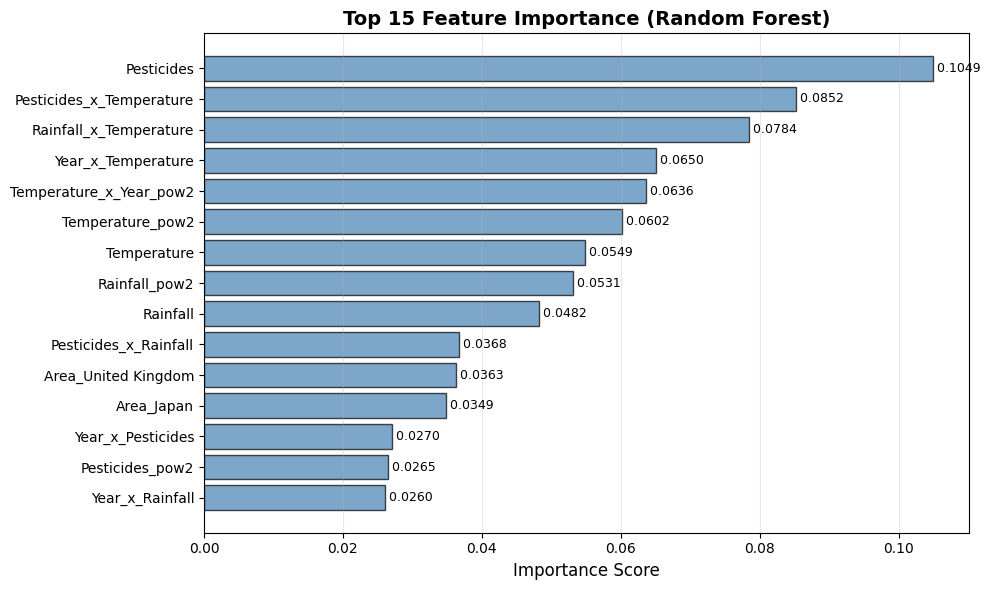

✓ Feature importance plot đã vẽ


In [19]:
# Vẽ biểu đồ feature importance
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).head(15)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(importance_df['Feature'], importance_df['Importance'], 
        color='steelblue', edgecolor='black', alpha=0.7)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

# Thêm giá trị lên các bar
for i, (feat, imp) in enumerate(zip(importance_df['Feature'], importance_df['Importance'])):
    ax.text(imp, i, f' {imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Feature importance plot đã vẽ")

## 5. Feature Selection

In [20]:
# Chọn top 15 features
n_features = 15
selected_features = builder.select_features(X_interaction, y, n_features=n_features)

print(f"\n✓ Đã chọn {len(selected_features)} features")
print(f"\nSelected features:")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feat}")


🎯 CHỌN TOP FEATURES

   Phương pháp: SelectKBest
   Số features: 15
   Scoring: f_regression

   ✓ Đã chọn 15 features:
       1. Year
       2. Pesticides
       3. Temperature
       4. Area_Australia
       5. Area_Ecuador
       6. Area_Egypt
       7. Area_Jamaica
       8. Area_Japan
       9. Area_New Zealand
      10. Area_Pakistan
      11. Area_United Kingdom
      12. Temperature_pow2
      13. Year_x_Year_pow2
      14. Pesticides_x_Year_pow2
      15. Temperature_x_Year_pow2

✓ Đã chọn 15 features

Selected features:
    1. Year
    2. Pesticides
    3. Temperature
    4. Area_Australia
    5. Area_Ecuador
    6. Area_Egypt
    7. Area_Jamaica
    8. Area_Japan
    9. Area_New Zealand
   10. Area_Pakistan
   11. Area_United Kingdom
   12. Temperature_pow2
   13. Year_x_Year_pow2
   14. Pesticides_x_Year_pow2
   15. Temperature_x_Year_pow2


In [21]:
# Lấy X với selected features
X_selected = builder.get_selected_dataframe(X_interaction)

print(f"\n📊 Final Feature Matrix:")
print(f"   Original (raw): {X.shape}")
print(f"   After engineering: {X_interaction.shape}")
print(f"   After selection: {X_selected.shape}")
print(f"\n   Reduction: {(1 - X_selected.shape[1]/X_interaction.shape[1])*100:.1f}%")


📊 Final Feature Matrix:
   Original (raw): (28242, 104)
   After engineering: (28242, 118)
   After selection: (28242, 15)

   Reduction: 87.3%


In [22]:
# Hiển thị 5 dòng đầu của selected features
print("\n🔍 5 Dòng Đầu Của Selected Features:")
display(X_selected.head())

print(f"\nThống kê:")
display(X_selected.describe())


🔍 5 Dòng Đầu Của Selected Features:


,Year,Pesticides,Temperature,Area_Australia,Area_Ecuador,Area_Egypt,Area_Jamaica,Area_Japan,Area_New Zealand,Area_Pakistan,Area_United Kingdom,Temperature_pow2,Year_x_Year_pow2,Pesticides_x_Year_pow2,Temperature_x_Year_pow2
0,-1.637075,-0.89887,-0.661406,False,False,False,False,False,False,False,False,0.437459,-4.387387,-2.408985,-1.77258
1,-1.637075,-0.89887,-0.661406,False,False,False,False,False,False,False,False,0.437459,-4.387387,-2.408985,-1.77258
2,-1.637075,-0.89887,-0.661406,False,False,False,False,False,False,False,False,0.437459,-4.387387,-2.408985,-1.77258
3,-1.637075,-0.89887,-0.661406,False,False,False,False,False,False,False,False,0.437459,-4.387387,-2.408985,-1.77258
4,-1.637075,-0.89887,-0.661406,False,False,False,False,False,False,False,False,0.437459,-4.387387,-2.408985,-1.77258



Thống kê:


,Year,Pesticides,Temperature,Temperature_pow2,Year_x_Year_pow2,Pesticides_x_Year_pow2,Temperature_x_Year_pow2
count,2.824200e+04,2.824200e+04,2.824200e+04,2.824200e+04,28242.000000,28242.000000,28242.000000
mean,5.217993e-15,8.855996e-17,5.716143e-16,1.000000e+00,0.012242,0.003128,0.006993
std,1.000018e+00,1.000018e+00,1.000018e+00,1.255077e+00,1.882509,1.292334,1.294535
min,-1.637075e+00,-9.024789e-01,-2.818956e+00,2.829586e-07,-4.387387,-2.418657,-7.128269
25%,-9.280345e-01,-8.516993e-01,-6.087108e-01,1.876543e-01,-0.799268,-0.632663,-0.314492
50%,-7.718558e-02,-3.794726e-01,1.531967e-01,6.371598e-01,-0.000460,-0.043071,0.006757
75%,9.154715e-01,5.501690e-01,8.647858e-01,1.160259e+00,0.767246,0.246906,0.554618
max,1.624512e+00,2.652971e+00,1.601732e+00,7.946511e+00,4.287154,7.001299,4.227036


## 6. Save Processed Data

In [23]:
# Lưu processed data
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Lưu X_selected với target
X_selected_with_target = X_selected.copy()
X_selected_with_target['Yield'] = y.values

X_selected_with_target.to_csv(output_dir / 'feature_engineered_data.csv', index=False)

print(f"\n💾 Đã lưu processed data:")
print(f"   {output_dir / 'feature_engineered_data.csv'}")
print(f"   Shape: {X_selected_with_target.shape}")


💾 Đã lưu processed data:
   ..\data\processed\feature_engineered_data.csv
   Shape: (28242, 16)


In [24]:
# Tóm tắt
print("\n" + "="*80)
print("✅ PREPROCESSING & FEATURE ENGINEERING HOÀN TẤT")
print("="*80)

print(f"\n📊 Summary:")
print(f"   • Original raw data: {df_merged.shape}")
print(f"   • After cleaning: {df_processed.shape}")
print(f"   • After feature engineering: {X_interaction.shape}")
print(f"   • After feature selection: {X_selected.shape}")
print(f"\n   • Features removed: {X_interaction.shape[1] - X_selected.shape[1]}")
print(f"   • Reduction ratio: {(1 - X_selected.shape[1]/X_interaction.shape[1])*100:.1f}%")


✅ PREPROCESSING & FEATURE ENGINEERING HOÀN TẤT

📊 Summary:
   • Original raw data: (28242, 6)
   • After cleaning: (28242, 105)
   • After feature engineering: (28242, 118)
   • After feature selection: (28242, 15)

   • Features removed: 103
   • Reduction ratio: 87.3%
